## 🌐 Application Streamlit deployee

**Lien direct :** https://cardio-predictor-ml.streamlit.app/

---

# Projet IA - Prediction des maladies cardiaques

Cours : Intelligence Artificielle et Apprentissage Automatique (Dr Arthur Sawadogo)

Auteurs : DIALLO Boukary, TIENDREBEOGO Ouahabou

Dataset : Heart Disease UCI (id=45) - https://archive.ics.uci.edu/dataset/45/heart+disease

Le but du projet est de predire si un patient est atteint d'une maladie cardiaque (1) ou non (0)
a partir de 13 caracteristiques cliniques (age, sexe, type de douleur, cholesterol, etc).


## 1. Importation des bibliotheques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report

# pour ignorer les warnings qui polluent l'affichage
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')


## 2. Chargement du jeu de donnees

In [2]:
# on utilise le package ucimlrepo pour recuperer directement le dataset
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features
y = heart_disease.data.targets

print("Dimensions X :", X.shape)
print("Dimensions y :", y.shape)


Dimensions X : (303, 13)
Dimensions y : (303, 1)


In [3]:
# affichage des premieres lignes
X.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


In [4]:
# informations sur les colonnes
X.info()


<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 30.9 KB


In [5]:
# statistiques descriptives
X.describe()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


## 3. Preparation des donnees

### 3.1. Binarisation de la variable cible

Dans le dataset UCI, la cible `num` prend des valeurs de 0 a 4 (0 = pas de maladie,
1 a 4 = maladie de gravite croissante). Comme demande dans l'enonce, on transforme
en variable binaire : 1 si maladie, 0 sinon.


In [6]:
print("Valeurs de num avant binarisation :")
print(y['num'].value_counts().sort_index())

# on cree la nouvelle variable target
y_bin = (y['num'] > 0).astype(int)

# on construit le dataframe complet pour faciliter l'analyse
df = X.copy()
df['target'] = y_bin

print("\nRepartition apres binarisation :")
print(df['target'].value_counts())


Valeurs de num avant binarisation :
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

Repartition apres binarisation :
target
0    164
1    139
Name: count, dtype: int64


### 3.2. Traitement des valeurs manquantes

In [7]:
# on regarde s'il y a des valeurs manquantes
df.isnull().sum()


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [8]:
# il y a 4 NaN dans 'ca' et 2 dans 'thal'
# on remplace par la mediane pour ca (variable numerique discrete)
# et par le mode pour thal (variable categorielle)

df['ca'] = df['ca'].fillna(df['ca'].median())
df['thal'] = df['thal'].fillna(df['thal'].mode()[0])

print("Total NaN apres remplacement :", df.isnull().sum().sum())


Total NaN apres remplacement : 0


## 4. Analyse exploratoire (EDA)

On va repondre aux differentes questions posees dans l'enonce.


### Question 1 : Quelle est la distribution de l'age ?

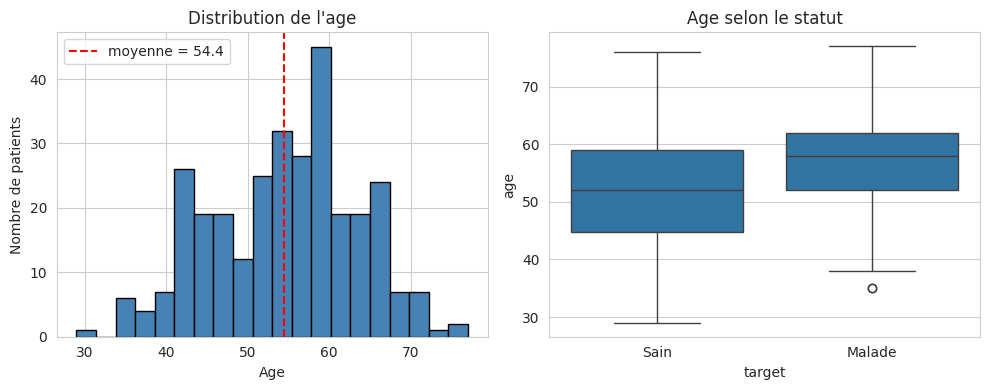

Age moyen des patients sains : 52.59
Age moyen des patients malades : 56.63


In [9]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df['age'], bins=20, color='steelblue', edgecolor='black')
plt.axvline(df['age'].mean(), color='red', linestyle='--', label=f"moyenne = {df['age'].mean():.1f}")
plt.xlabel('Age')
plt.ylabel('Nombre de patients')
plt.title("Distribution de l'age")
plt.legend()

plt.subplot(1, 2, 2)
sns.boxplot(x='target', y='age', data=df)
plt.xticks([0, 1], ['Sain', 'Malade'])
plt.title("Age selon le statut")

plt.tight_layout()
plt.show()

print("Age moyen des patients sains :", round(df[df['target']==0]['age'].mean(), 2))
print("Age moyen des patients malades :", round(df[df['target']==1]['age'].mean(), 2))


On observe que la majorite des patients a entre 50 et 65 ans. Les patients malades
sont en moyenne legerement plus ages que les patients sains.

### Question 2 : Y a-t-il une difference entre les sexes ?

In [10]:
# tableau croise sexe x target
tableau_sexe = pd.crosstab(df['sex'], df['target'])
tableau_sexe.index = ['Femme', 'Homme']
tableau_sexe.columns = ['Sain', 'Malade']
print(tableau_sexe)


       Sain  Malade
Femme    72      25
Homme    92     114


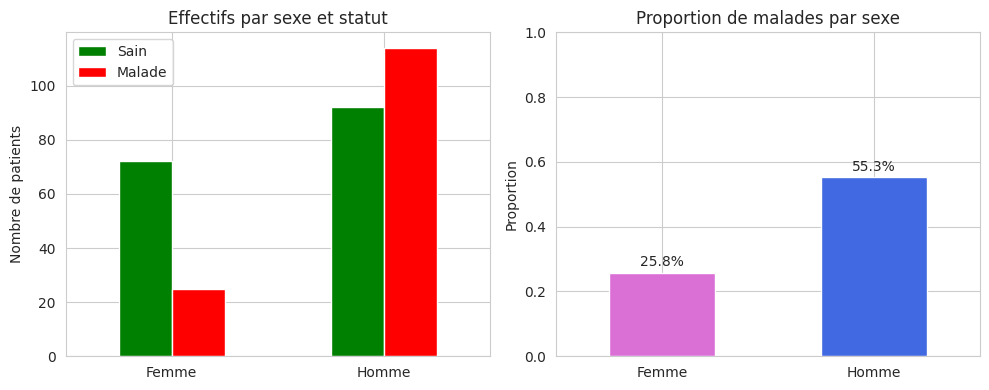

In [11]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
tableau_sexe.plot(kind='bar', ax=plt.gca(), color=['green', 'red'])
plt.title('Effectifs par sexe et statut')
plt.xticks(rotation=0)
plt.ylabel('Nombre de patients')

plt.subplot(1, 2, 2)
proportion = df.groupby('sex')['target'].mean()
proportion.index = ['Femme', 'Homme']
proportion.plot(kind='bar', color=['orchid', 'royalblue'])
plt.title('Proportion de malades par sexe')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.ylim(0, 1)
for i, v in enumerate(proportion.values):
    plt.text(i, v + 0.02, f"{v:.1%}", ha='center')

plt.tight_layout()
plt.show()


Les hommes sont beaucoup plus touches que les femmes dans cet echantillon.

### Question 3 : Lien entre le type de douleur thoracique (cp) et la maladie

In [12]:
# rappel des codes : 1=angine typique, 2=angine atypique, 3=non angineuse, 4=asymptomatique
labels_cp = ['Angine typique', 'Angine atypique', 'Non angineuse', 'Asymptomatique']

tableau_cp = pd.crosstab(df['cp'], df['target'])
tableau_cp.index = labels_cp
tableau_cp.columns = ['Sain', 'Malade']
print(tableau_cp)


                 Sain  Malade
Angine typique     16       7
Angine atypique    41       9
Non angineuse      68      18
Asymptomatique     39     105


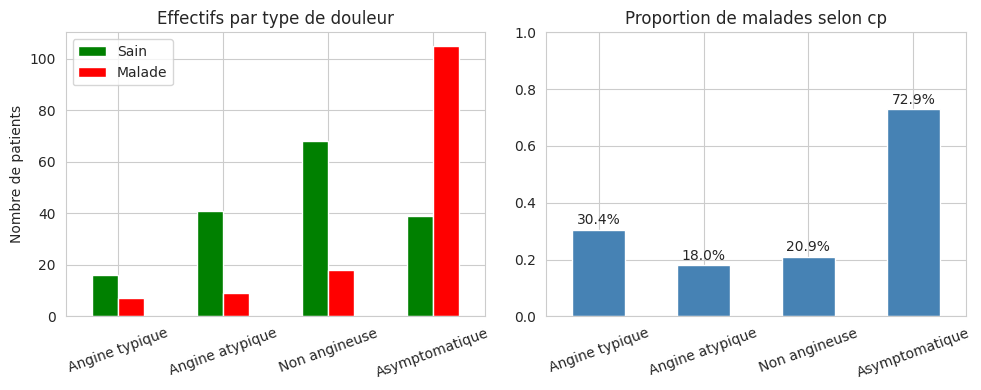

In [13]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
tableau_cp.plot(kind='bar', ax=plt.gca(), color=['green', 'red'])
plt.title('Effectifs par type de douleur')
plt.xticks(rotation=20)
plt.ylabel('Nombre de patients')

plt.subplot(1, 2, 2)
prop_cp = df.groupby('cp')['target'].mean()
prop_cp.index = labels_cp
prop_cp.plot(kind='bar', color='steelblue')
plt.title('Proportion de malades selon cp')
plt.xticks(rotation=20)
plt.ylim(0, 1)
for i, v in enumerate(prop_cp.values):
    plt.text(i, v + 0.02, f"{v:.1%}", ha='center')

plt.tight_layout()
plt.show()


On constate que les patients avec une douleur asymptomatique (cp=4) sont les plus
souvent malades (~75%). C'est etonnant, mais en realite l'angine asymptomatique est
souvent le signe d'une maladie deja installee.

### Question 4 : Moyennes de trestbps, chol et thalach par statut

In [14]:
moyennes = df.groupby('target')[['trestbps', 'chol', 'thalach']].mean().round(2)
moyennes.index = ['Sain', 'Malade']
print(moyennes)


        trestbps    chol  thalach
Sain      129.25  242.64   158.38
Malade    134.57  251.47   139.26


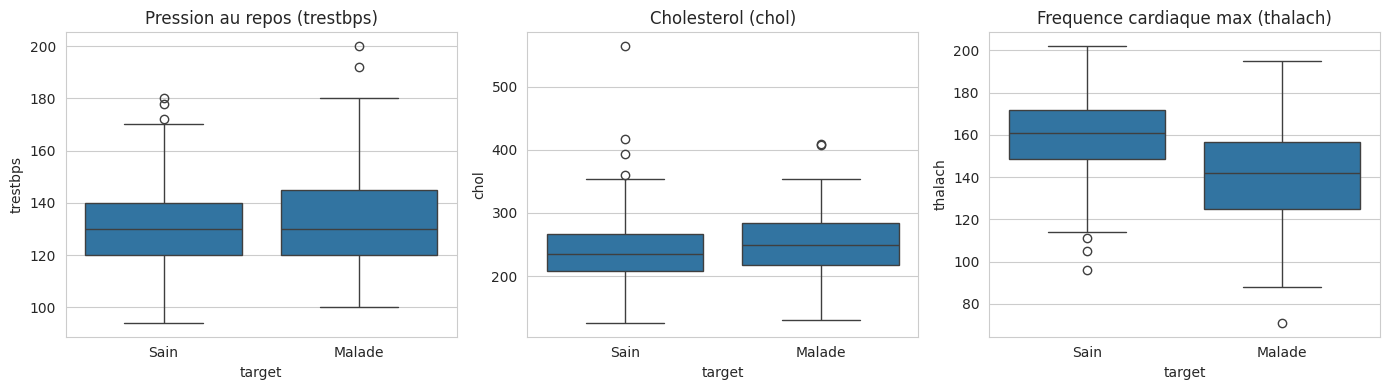

In [15]:
# on visualise avec des boxplots pour mieux comprendre
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

variables = ['trestbps', 'chol', 'thalach']
titres = ['Pression au repos (trestbps)', 'Cholesterol (chol)', 'Frequence cardiaque max (thalach)']

for i in range(3):
    sns.boxplot(x='target', y=variables[i], data=df, ax=axes[i])
    axes[i].set_xticklabels(['Sain', 'Malade'])
    axes[i].set_title(titres[i])

plt.tight_layout()
plt.show()


On voit que la frequence cardiaque maximale (thalach) est nettement plus basse
chez les patients malades. La pression et le cholesterol sont moins discriminants.

### Question 5 : Lien entre fbs (glycemie a jeun > 120) et la maladie

In [16]:
tableau_fbs = pd.crosstab(df['fbs'], df['target'], normalize='index') * 100
tableau_fbs.index = ['fbs <= 120', 'fbs > 120']
tableau_fbs.columns = ['% Sain', '% Malade']
print(tableau_fbs.round(2))


            % Sain  % Malade
fbs <= 120   54.65     45.35
fbs > 120    51.11     48.89


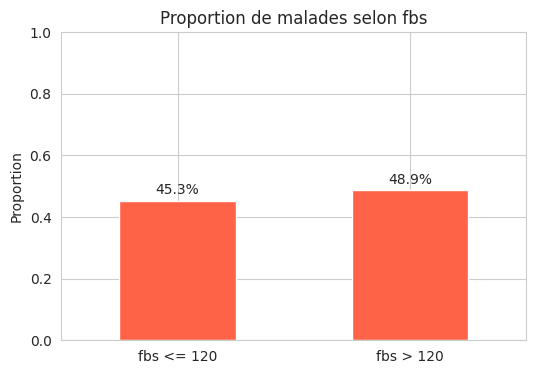

In [17]:
plt.figure(figsize=(6, 4))
prop_fbs = df.groupby('fbs')['target'].mean()
prop_fbs.index = ['fbs <= 120', 'fbs > 120']
prop_fbs.plot(kind='bar', color='tomato')
plt.title('Proportion de malades selon fbs')
plt.ylabel('Proportion')
plt.ylim(0, 1)
plt.xticks(rotation=0)
for i, v in enumerate(prop_fbs.values):
    plt.text(i, v + 0.02, f"{v:.1%}", ha='center')
plt.show()


La glycemie a jeun ne semble pas etre un bon indicateur, les proportions sont tres proches.

### Question 6 : Lien entre exang (angine d'effort) et la maladie

In [18]:
tableau_exang = pd.crosstab(df['exang'], df['target'], normalize='index') * 100
tableau_exang.index = ['Pas d angine', 'Angine']
tableau_exang.columns = ['% Sain', '% Malade']
print(tableau_exang.round(2))


              % Sain  % Malade
Pas d angine   69.12     30.88
Angine         23.23     76.77


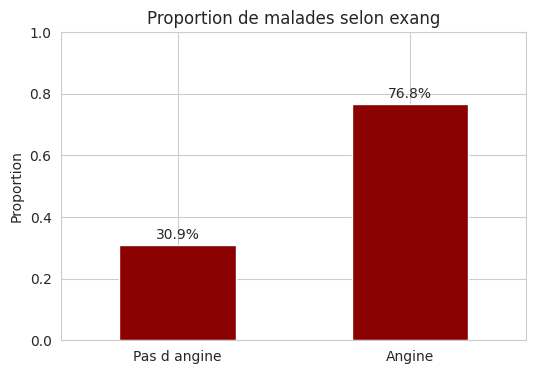

In [19]:
plt.figure(figsize=(6, 4))
prop_ex = df.groupby('exang')['target'].mean()
prop_ex.index = ['Pas d angine', 'Angine']
prop_ex.plot(kind='bar', color='darkred')
plt.title('Proportion de malades selon exang')
plt.ylabel('Proportion')
plt.ylim(0, 1)
plt.xticks(rotation=0)
for i, v in enumerate(prop_ex.values):
    plt.text(i, v + 0.02, f"{v:.1%}", ha='center')
plt.show()


Il y a clairement plus de malades parmi ceux qui font une angine a l'effort (~76%).

### Matrice de correlation

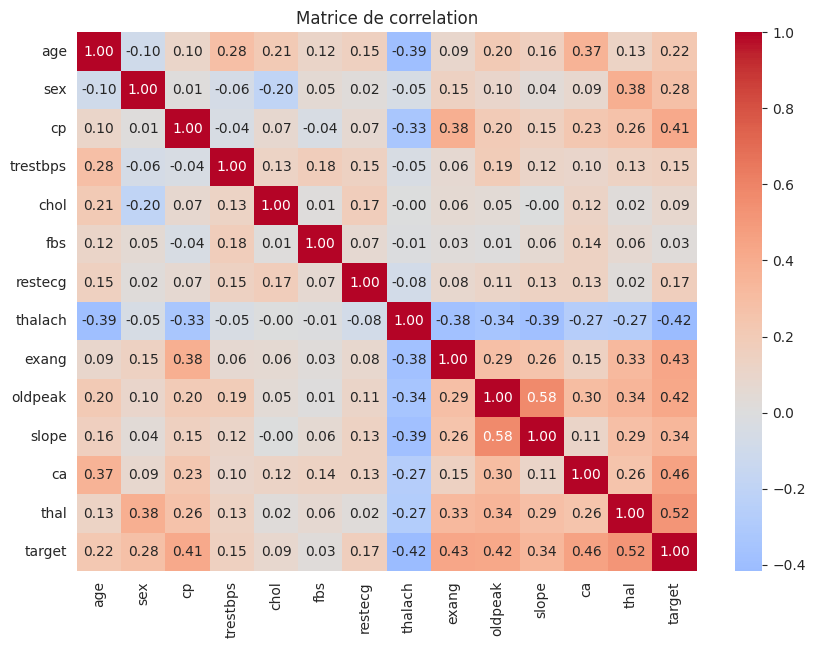

In [20]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Matrice de correlation')
plt.show()


Les variables les plus correlees a target sont : cp, exang, oldpeak, ca, thal,
thalach (correlation negative car les malades ont une FC max plus basse).

## 5. Preparation pour l'apprentissage

On separe les variables explicatives (X) et la cible (y), puis on fait un split
train/test (80/20) en stratifiant pour conserver les proportions.


In [21]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Taille train :", X_train.shape)
print("Taille test  :", X_test.shape)


Taille train : (242, 13)
Taille test  : (61, 13)


In [22]:
# certains algos comme KNN et SVM sont sensibles a l'echelle des variables
# on applique donc un StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)


## 6. Entrainement des 6 algorithmes de classification

On entraine et on evalue les 6 algorithmes demandes :
- Regression logistique
- KNN
- SVM
- Arbre de decision
- Random Forest
- AdaBoost


In [23]:
modeles = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=7),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'DecisionTree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, random_state=42),
}

resultats = []
modeles_entraines = {}

for nom, modele in modeles.items():
    # entrainement
    modele.fit(X_train_sc, y_train)

    # predictions
    y_pred = modele.predict(X_test_sc)
    y_proba = modele.predict_proba(X_test_sc)[:, 1]

    # metriques
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    resultats.append({
        'Modele': nom,
        'Accuracy': acc,
        'Precision': prec,
        'Rappel': rec,
        'F1-Score': f1,
        'AUC-ROC': auc
    })
    modeles_entraines[nom] = modele

df_resultats = pd.DataFrame(resultats).set_index('Modele').round(4)
df_resultats.sort_values('F1-Score', ascending=False)


,Accuracy,Precision,Rappel,F1-Score,AUC-ROC
Modele,,,,,
RandomForest,0.9016,0.8438,0.9643,0.9000,0.9551
AdaBoost,0.9016,0.8438,0.9643,0.9000,0.9740
LogisticRegression,0.8689,0.8125,0.9286,0.8667,0.9513
SVM,0.8525,0.8065,0.8929,0.8475,0.9437
KNN,0.8361,0.7647,0.9286,0.8387,0.9453
DecisionTree,0.7705,0.7059,0.8571,0.7742,0.8030


### 6.1. Comparaison graphique des metriques

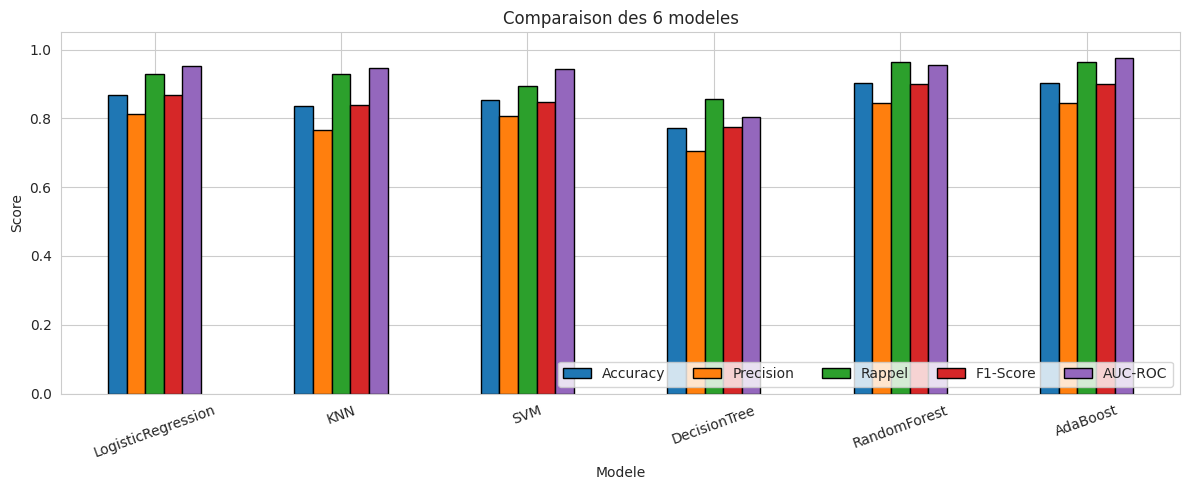

In [24]:
df_resultats.plot(kind='bar', figsize=(12, 5), edgecolor='black')
plt.title('Comparaison des 6 modeles')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.legend(loc='lower right', ncol=5)
plt.tight_layout()
plt.show()


### 6.2. Courbes ROC

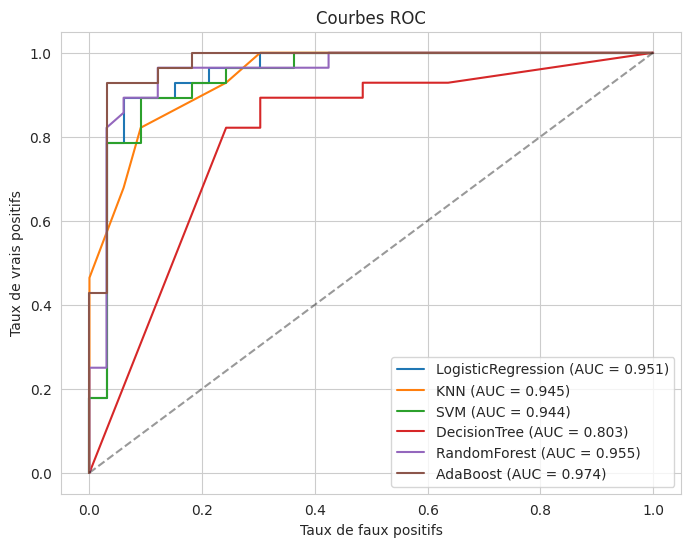

In [25]:
plt.figure(figsize=(8, 6))

for nom, modele in modeles_entraines.items():
    y_proba = modele.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{nom} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbes ROC')
plt.legend(loc='lower right')
plt.show()


### 6.3. Matrices de confusion

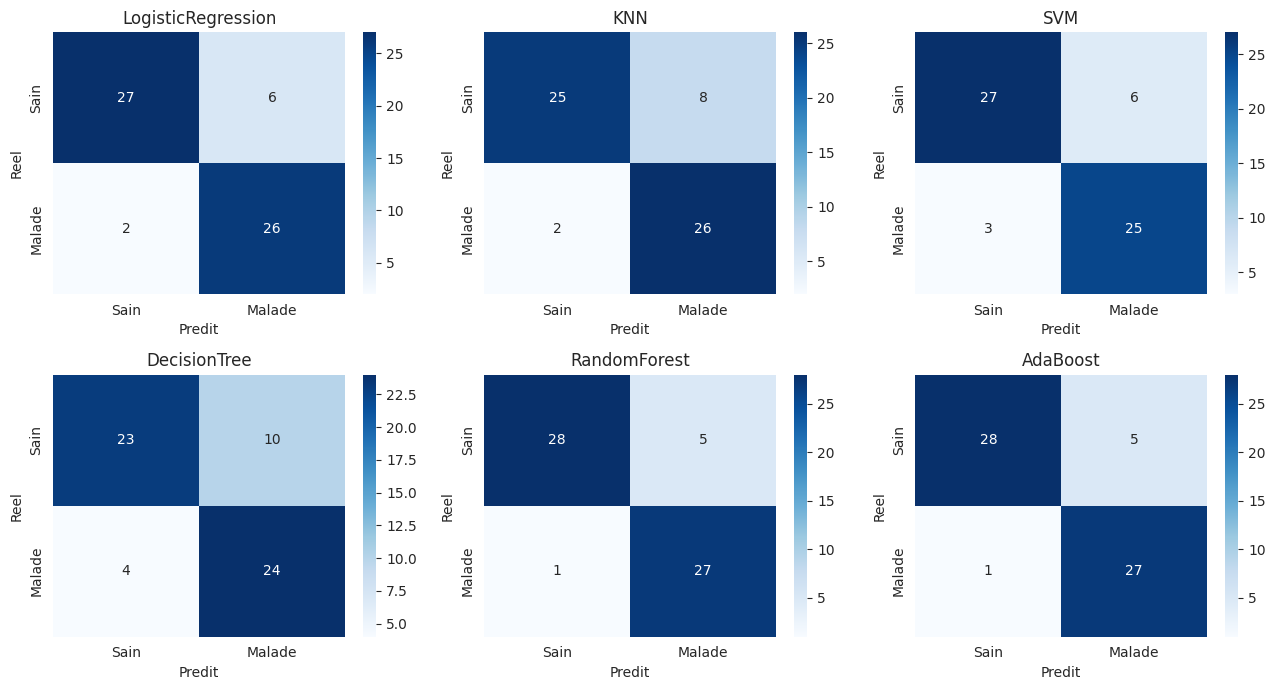

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

for i, (nom, modele) in enumerate(modeles_entraines.items()):
    cm = confusion_matrix(y_test, modele.predict(X_test_sc))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Sain', 'Malade'],
                yticklabels=['Sain', 'Malade'],
                ax=axes[i])
    axes[i].set_title(nom)
    axes[i].set_xlabel('Predit')
    axes[i].set_ylabel('Reel')

plt.tight_layout()
plt.show()


### 6.4. Rapport detaille du meilleur modele

In [27]:
# on prend celui qui a le meilleur F1-Score
meilleur_nom = df_resultats['F1-Score'].idxmax()
meilleur_modele = modeles_entraines[meilleur_nom]

print("Meilleur modele :", meilleur_nom)
print()
print(classification_report(y_test, meilleur_modele.predict(X_test_sc),
                            target_names=['Sain', 'Malade']))


Meilleur modele : RandomForest

              precision    recall  f1-score   support

        Sain       0.97      0.85      0.90        33
      Malade       0.84      0.96      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.91      0.90        61
weighted avg       0.91      0.90      0.90        61



## 7. Sauvegarde des modeles pour l'application Streamlit

On sauvegarde le scaler et chaque modele dans le dossier `models/` afin de pouvoir
les recharger dans l'application web.


In [28]:
import os
os.makedirs('../models', exist_ok=True)

# on sauvegarde le scaler
joblib.dump(scaler, '../models/scaler.pkl')

# on sauvegarde tous les modeles
for nom, modele in modeles_entraines.items():
    joblib.dump(modele, f'../models/{nom}.pkl')

# on sauvegarde aussi le meilleur modele a part et les resultats
joblib.dump(meilleur_modele, '../models/best_model.pkl')
joblib.dump(df_resultats, '../models/results.pkl')
joblib.dump({'best_name': meilleur_nom, 'features': list(X.columns)}, '../models/metadata.pkl')

print("Sauvegarde OK dans le dossier models/")


Sauvegarde OK dans le dossier models/


## 8. Conclusion

D'apres les resultats obtenus :

- Le meilleur modele en termes de F1-Score est **Random Forest**.
- Les algorithmes d'ensemble (Random Forest, AdaBoost) donnent les meilleures performances.
- L'arbre de decision simple est le moins performant car il a tendance a sur-apprendre.

Les variables les plus utiles pour la prediction sont :
`cp`, `exang`, `oldpeak`, `thalach`, `ca`, `thal`.

L'application Streamlit permet de :
1. visualiser les analyses exploratoires,
2. comparer les modeles,
3. faire une prediction sur un nouveau patient.

Pour lancer l'application :
```
streamlit run app.py
```
